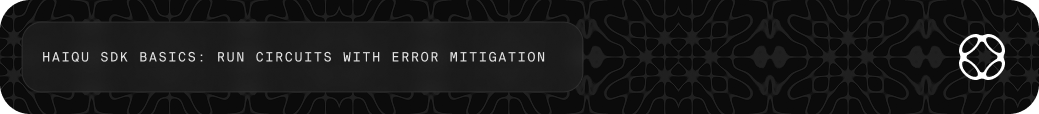

This notebook demonstrates how to use mitigation when executing your quantum circuits with `haiqu.run(use_mitigation=True)`.

- Haiqu SDK can automatically apply **lightweight** error mitigation to both sampling and expectation value estimation tasks
- For an adder circuit starting at around **17.3%** success probability, mitigation can boost the success probability significantly up to **85% (4.9x)**

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.run(use_mitigation=True)`

- **What does it do?** This parameter enables quantum error mitigation when executing quantum circuits on supported devices, helping to improve the accuracy of results.
- **How do I use it?** You just need to set `use_mitigation=True` when calling `haiqu.run()`. The mitigation process will be applied automatically if supported by the backend.
- **What are the options?** It is possible to customize the error mitigation pipeline by turning specific components on or off. Refer to the documentation for more details.
- **Which option do you recommend?** Start with testing out error mitigation on small scale sampling tasks. Then move to mitigating expectation values of observables and more complex circuits as you gain confidence.

**Note:** this notebook assumes some basic knowledge of Haiqu SDK. Make sure to read through [`haiqu_run.ipynb`](./haiqu_run.ipynb) notebook first.

## Initialize the example

Import the necessary libraries, initialize the Haiqu SDK, and create a quantum circuit to demonstrate error mitigation. In this example we return to using quantum adder circuit. The adder circuit adds two integers m and k.

In [ ]:
import pandas as pd
from haiqu.sdk import haiqu, set_haiqu_mpl_style

haiqu.login()
haiqu.init("Haiqu Run Use Mitigation Job Tutorial")
set_haiqu_mpl_style()

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
import numpy as np

def build_adder_circuit(num_qubits, m, k):
    """
    Builds a quantum circuit that adds integer k to m using the QFT.

    Parameters:
    - num_qubits (int): Number of qubits.
    - m (int): Initial value.
    - k (int): Value to add.

    Returns:
    - QuantumCircuit implementing |m⟩ -> |m + k⟩ with measurement.
    - Binary strings for m and m+k (for verification).
    """
    m_binary = f"{m:0{num_qubits}b}"
    m_plus_k_binary = f"{m + k:0{num_qubits}b}"
    adder = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        if m_binary[i] == "1":
            adder.x(num_qubits - 1 - i)
    adder.compose(QFTGate(num_qubits), inplace=True)
    for i in range(num_qubits):
        adder.rz(k * np.pi / 2**i, num_qubits - i - 1)
    adder.compose(QFTGate(num_qubits).inverse(), inplace=True)
    adder.measure_all()
    return adder, m_binary, m_plus_k_binary

adder, m_binary, m_plus_k_binary = build_adder_circuit(num_qubits=10, m=343, k=19)
haiqu.draw(adder)

## Execute the quantum circuit with error mitigation enabled

To run on a particular quantum device, we need to specify our credentials in the `options` parameter of the `haiqu.run()` function. We will use `fake_torino` as a device for demonstration purposes, but you can replace it with the real `ibm_torino` (or any other device) from the list obtained from using `haiqu.list_devices()` or `haiqu.list_simulators()`, as long as you have access to it.

In [3]:
device = haiqu.get_device("fake_torino")
options = {}

# Uncomment the following lines to run on the actual IBM Quantum device
# device = haiqu.get_device("ibm_torino")  

# options = {
#     "ibm_quantum_token": "YOUR_IBM_QUANTUM_API_KEY",  # Replace with your IBM Quantum API key
#     "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE_ID",  # Replace with your IBM Quantum instance ID if needed
# }

scenarios = [
    {"device": haiqu.get_device("aer_simulator"), "options": {}, "use_mitigation": False, "description": "Ideal Result"},
    {"device": device, "options": options, "use_mitigation": False, "description": f"{device.id} w/o mitigation"},
    {"device": device, "options": options, "use_mitigation": True, "description": f"{device.id} with mitigation"},
]

### Submit Jobs

In [4]:
# Submit jobs and save job IDs
saved_job_ids = {}
for scenario in scenarios:
    job = haiqu.run(
        adder,
        device=scenario["device"],
        options=scenario["options"],
        shots=8192,
        use_mitigation=scenario["use_mitigation"],
    )
    saved_job_ids[scenario["description"]] = job.id
    print(f"{scenario['description']}: {job.id}")

Ideal Result: jb-399e271b-a647-4a97-9baf-80883e9f4d36
fake_torino w/o mitigation: jb-a4c66bde-fa21-46db-b6d0-85417d030fff
fake_torino with mitigation: jb-9206785a-2385-407e-b4aa-a5c5faa7b070


### Retrieve Results
Run this cell to get results once jobs are complete. For real QPU jobs, this may take minutes to hours. You can close the notebook and come back later—just use the saved job IDs to retrieve results in a new session.

**Note:** `job.result()` is a blocking call. If the job is not complete, it will wait until results are ready.

In [5]:
# Retrieve results from saved job IDs
results = []
for name, job_id in saved_job_ids.items():
    job = haiqu.get_job(job_id)
    print(f"{name}: {job.retrieve_status()}")
    result = job.result()
    results.append({"description": name, "probability": result[0].get(m_plus_k_binary, 0)})

Ideal Result: JobStatus.DONE
fake_torino w/o mitigation: JobStatus.INITIALIZING
fake_torino with mitigation: JobStatus.DONE


In [6]:
def build_summary(results):
    """Build summary table data from experiment results."""
    baseline = results[1]["probability"]
    return {
        "Configuration": [r["description"] for r in results],
        "Success Probability": [f'{r["probability"]:.1%}' for r in results],
        "Improvement": [""] + ["Noisy Baseline"] + [f'{(results[2]["probability"]/baseline):.1f}x'],
    }

print(pd.DataFrame(build_summary(results)))

                 Configuration Success Probability     Improvement
0                 Ideal Result              100.0%                
1   fake_torino w/o mitigation               19.1%  Noisy Baseline
2  fake_torino with mitigation               82.2%            4.3x


> Note: due to the sampling errors and variability of the noise on quantum devices, results, and the effect of noise mitigation in particular, may differ between runs. You may want to run the same cell multiple times to see the range of possible outcomes and get a better sense of the impact of error mitigation.

> **💡 Good to Know:** It is also possible to use error mitigation for expectation value estimation tasks, as described in [noise mitigation techniques](https://docs.haiqu.ai/core_features/error_shield).

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

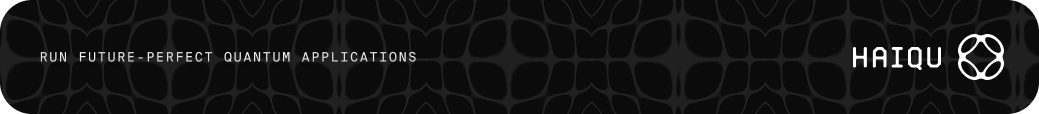